In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#setup for poor housing conditions
housing = pd.read_csv("poorhousingconditions.csv")
asbestos = pd.read_csv("asbestos.csv")

def filterLess (x, column, filtVal):
    abc = x[x[column].astype(float) >= filtVal]
    return abc

tenPercent = filterLess(housing, 'PPoorCon', .1)
df = tenPercent.assign(Neighborhood= [
    'North Fayette', 'North Braddock', 'North Braddock',
    'North Braddock', 'Rankin', 'McKeesport',
    'McKeesport', 'McKeesport', 'Wilkinsburg',
    'Wilkinsburg', 'McKeesport', 'Forward',
    'Wilmerding', 'Duquense', 'Homestead',
    'Frazer Township', 'Harrison Township', 'Wilkinsburg',
    'Braddock', 'Spring Garden', 'Turtle Creek',
    'Etna', 'Clairton', 'Duquense'
    ])


# Worst Neighborhoods in Pittsburgh

### URL's to Data Sets used
*  https://data.wprdc.org/dataset/allegheny-county-poor-condition-residential-parcel-rates
*  https://data.wprdc.org/dataset/allegheny-county-asbestos-permit

##### We got our datasets from the WPRDC website.  They contian information on poor housing conditoins and asbestos permit data.

## Intoduction
#### To determine the worst neighborhood, we decided to compare the poor housing conditions and the asbestos in Allegheney County.  We chose these datasets because they directly affect the health and quality of life of the people in the neighborhoods.  Initially we had set out to discover the best neighborhood, and we intended to use, among other things, data on bike routes and income.  However, circumstances were set so that calculating neighborhoods with the worst standard of living would be better.  We were influenced by the poor housing dataset because we decided to restrict our analysis to only include neighborhoods where poor conditions are greater than or equal to ten percent.  After doing this, we decided to assign more weight to the poor housing conditions when calculating standard of living.  This was due to the fact that poor housing is more general and can include multiple health and social risks.  The final poor housing score for each neighborhood is based off of the multiple of average poor condition percentage and quantity of entries.  Each score was then divided by the max value in the poor housing metric dataset to represent each neighborhood's rankning (in terms of housing) as a number between one and zero.  The asbestos metric score was calculated by multiplying the total sqare feet covered in each neighborhood by the quantity of entries.  These scores were also divided by the max value in the asbestos metric dataset to reflect ranking (in terms of asbestos) as a number between one and zero.  Not every neighborhood in the poor housing dataset appeared in the asbestos dataset, so they were assigned values of zero to reflect that no asbestos data had been collected.  This decision ended up making neighborhoods that scored zero for asbestos have a slightly higher standard of living. This could potentially be misleading because it is unclear whether they didn't appear because there is insufficient data or whether there was actually no asbestos.  Regardless, the final metric for standard of living was calculated by adding the ranking for housing metric and asbestos metric together.

## Metric

#### To determine which Pittsburgh neighborhoods are the worst, we judged communities based on the standard of living their residents have.  Factoring into how we calculated standard of living are poor housing conditoins and asbestos.  Poor housing conditions received a slightly higher weight.  If more than 10% of people in a neighborhood had poor housing conditions, that community was automatically a contender for worst neighborhood.  Asbestos data was then gathered for each of the communities that had more than 10% poor housing conditions. With regard to poor housing, neighborhoods were scored based on average percentage as well as quantity of entries.  When considering Asbestos, neighborhoods were given a score according to total square feet and quantity of entries.  For each measurement, neighborhoods received a score based off of how close it was to the maximum metric for either dataset.  Higher scores are worse.  This was how we determined  which communities have the lowest standard of living.

### Poor Housing Conditoins

#### This chart is based on a dataset from WPRDC which tracks the percentage of poor housing conditions in each census tract.  
#### It has been modified to use the neighborhood as the index, and only displays data regarding tracts with poor conditions greater than %10
#### Each census tract with poor housing conditions over 10% was collected into a new dataset so that we could focus on the neighborhoods with the lowest overall standards of living.  We accomplished this by using a filter function to filter out entries with poor conditoins lower than .10 (10 percent).

In [2]:
display(df['PPoorCon'].describe())
df.sort_values(by=['TRACT']).set_index('Neighborhood')


count    24.000000
mean      0.154636
std       0.050970
min       0.100973
25%       0.112580
50%       0.129688
75%       0.204757
max       0.256312
Name: PPoorCon, dtype: float64

,TRACT,PPoorCon
Neighborhood,,
Spring Garden,241200,0.126110
Harrison Township,401200,0.124040
Frazer Township,405000,0.116105
Etna,425000,0.106359
Homestead,483800,0.111111
Duquense,486800,0.145397
Duquense,486900,0.100973
Clairton,492700,0.107236
Forward,495000,0.113070


#### Using neighborhood as the index, we calculated the average poor conditions and number of entries each neighborhood had.
#### The column labled AvgPPoorCon represents the average poor conditions in each neighborhood.  It divides the total percentage by the total number of tracts with poor conditions over 10% in each neighborhood that has a tract greater than 10%. 
#### The column labled quantity kepps track of how many times each neighborhood appeared in our filtered dataset.

In [3]:
quantity = df['Neighborhood'].value_counts()
avg = df.groupby('Neighborhood').mean()
new = avg.drop(columns=['TRACT']).rename(columns={'PPoorCon': 'AvgPPoorCon'})
new['quantity']= quantity

stupid = new.reset_index()

new

,AvgPPoorCon,quantity
Neighborhood,,
Braddock,0.143345,1
Clairton,0.107236,1
Duquense,0.123185,2
Etna,0.106359,1
Forward,0.113070,1
Frazer Township,0.116105,1
Harrison Township,0.124040,1
Homestead,0.111111,1
McKeesport,0.218043,4


#### The top graph represents the average poor housing conditions for each of the 16 most impoverished neighborhoods.  The black line represents the average of every entry over 10%.
#### The bottom graph represents the number of times each of the 16 neighborhoods with the worst housing conditions has a census tract where the percentage of poor living conditions is above 10%.

Text(0,0.5,'number of Tracts')

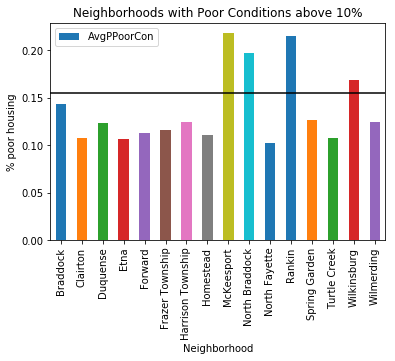

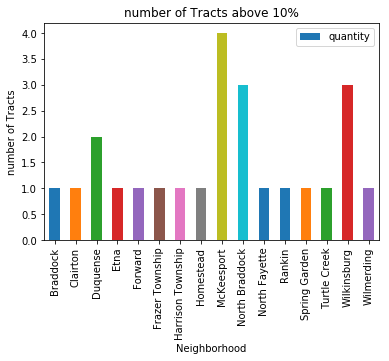

In [4]:
avgComp = new.plot.bar(y = 'AvgPPoorCon', title="Neighborhoods with Poor Conditions above 10%")
plt.axhline(df['PPoorCon'].mean(), color='k');
plt.ylabel('% poor housing')



quantityComp = new.plot.bar(y = 'quantity', title="number of Tracts above 10%")
plt.ylabel('number of Tracts')


#### We assigned each neighborhood a value based on the multiple of average poor housing conditions and quantity of entries.  
#### All multiples were divided by the max value to get a score judging worst neighborhood based solely on poor housing conditions.
#### The greatest value was assigned a one, so values closer to one are worse.

,Poor Housing Metric
Neighborhood,
McKeesport,1.000000
North Braddock,0.676703
Wilkinsburg,0.579262
Duquense,0.282479
Rankin,0.246887
Braddock,0.164354
Spring Garden,0.144593
Harrison Township,0.142220
Wilmerding,0.142217


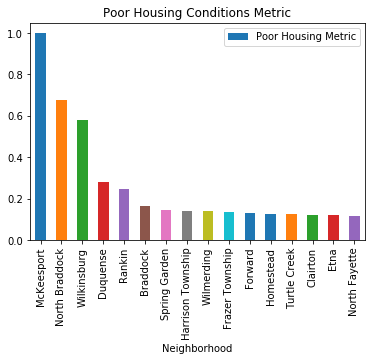

In [5]:
#metric gathered from poor conditions

new['Poor Housing Metric'] = new['AvgPPoorCon']*new['quantity']
maxPercent = new['Poor Housing Metric'].max()

poorConMetric = new.divide(maxPercent).drop(columns = ['AvgPPoorCon','quantity']).sort_values(['Poor Housing Metric'], ascending=False)
display(poorConMetric)
poorConditionMetricGraph = poorConMetric.plot.bar(y = 'Poor Housing Metric', title='Poor Housing Conditions Metric')


#### When considering only poor housing conditions, the worst neighborhood is McKeesport. 

## Asbestos Permits

#### We refined our initial dataset so that the index was based by city (neighborhood) and it only reflects neighborhoods that appeared in our poor housing conditions dataset.
#### We limited our columns to square feet and quantity to make the pertinent data more clear.

In [6]:
asbestosSorted = asbestos.sort_values(by ='city')
quantity = asbestosSorted['city'].value_counts()
total = asbestosSorted.drop(columns =['s_name','s_address', 'z_code', 'p_fee', 'c_number',
                                      'contractor', 'permit_specifications',
                                      'i_date', 'e_date', 'achd_inspector', 'job_complete',
                                      'is_permit_date_extended','permit_o_e_date','project_type',
                                      'latitude', 'longitude'])

options = ['BRADDOCK', 'CLAIRTON', 'NORTH FAYETTE', 
           'NORTH BRADDOCK', 'RANKIN', 'MCKEESPORT', 
           'WILKINSBURG', 'FORWARD', 'WILMERDING', 'DUQUENSE', 
           'HOMESTEAD', 'FRAZER TOWNSHIP', 'HARRISON TOWNSHIP', 
           'SPRING GARDEN', 'TURTLE CREEK', 'ETNA'] 
  
newDF = total[total['city'].isin(options)] 

totQuant= newDF.groupby(by=['city']).mean()
totQuant['quantity'] = quantity
totQuant

,square_feet,quantity
city,,
BRADDOCK,2271.600000,5
CLAIRTON,6744.454545,22
ETNA,7517.500000,2
HOMESTEAD,1353.444444,9
MCKEESPORT,2655.588235,17
WILMERDING,18440.000000,1


#### The top graph represents the total square feet marked on asbestos permits.  The black line represents the average of all the entries of square feet for the six neighborhoods we focused on.
#### The bottom graph represents the total number of permits submitted for each neighborhood.

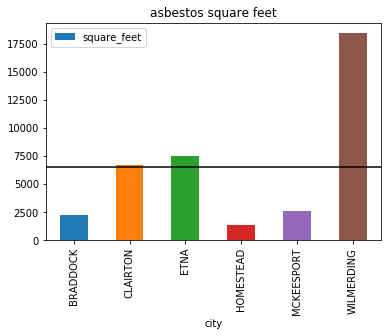

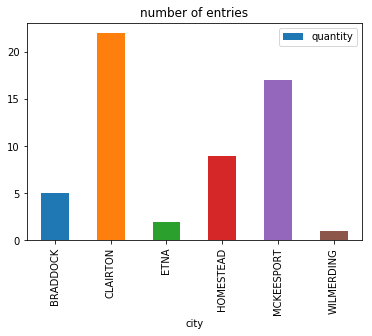

In [10]:
asbestosSqFtAvg = totQuant.plot.bar(y = 'square_feet', title='asbestos square feet')
plt.axhline(totQuant['square_feet'].mean(), color='k');

asbestosQuant = totQuant.plot.bar(y = 'quantity', title='number of entries')


#### We assigned each neighborhood a value based on the multiple of square feet and quantity of permits.  
#### All multiples were divided by the max value to get a score judging worst neighborhood based solely on asbestos.
#### The greatest value was assigned a one, so values closer to one are worse.

,Asbestos Metric
city,
CLAIRTON,1.000000
MCKEESPORT,0.304257
WILMERDING,0.124277
ETNA,0.101329
HOMESTEAD,0.082094
BRADDOCK,0.076548


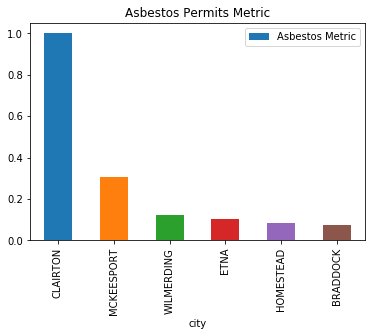

In [8]:
totQuant['Asbestos Metric'] = totQuant['square_feet']*totQuant['quantity']
maxPercent = totQuant['Asbestos Metric'].max()

asbestosMetric = totQuant.divide(maxPercent).drop(columns = ['square_feet','quantity']).sort_values(['Asbestos Metric'], ascending=False)

display(asbestosMetric)

asbestosMetricGraph = asbestosMetric.plot.bar(y = 'Asbestos Metric', title='Asbestos Permits Metric')


## Final Judgement for Worst Neighborhoods

#### The values for each neighborhood's asbestos and poor housing rankings were added together to get the final metric for standard of living.

1. Mckeesport 1.304257
2. Clariton 1.122953
3. North Braddock 0.676703
4. Wilkinsburg .579262
5. Duquense  .282479
6. Wilmerding .266494
7. Rankin.246887
8. Braddock .240902
9. Etna .223276
10. Homestead .204041
11. Spring Garden .144593
12. Harrison Township .142220
13. Frazer Township .133122
14. Forward .129642
15. Turtle Creek  .123697
16. North Fayette  .117716

## Conclusion

#### In closing, based on the data we’ve examined thus far, McKeesport won the award for worst neighborhood with Clairton not far behind. Of course, this isn’t a definitive measurement, and it is up to the individual to decide what matters more to you as a resident: poor housing or asbestos use. To those with chronic respiratory issues, maybe asbestos has a greater personal burden on you than housing conditions do, while to those who value curb appeal, McKeesport maybe isn’t for you. Moreover, as it stands now, this judgement is a result of only two datasets; we have set aside several other sets of data that we’d like to examine, though due to time constraints, we have yet to examine that data. By the end we hope to compare the data we have currently to WPRDC data pertaining to air quality and crime rates.

## Independent Conclusions

#### Independent Conclusion - David Reidenbaugh
#### I haven't spent much time in most of the neighborhoods on this list, so it is difficult for me to have an opionion on the matter of neighborhood with lowest standard of living in Pittsburgh.  The data definitley aligns with the reputations of neighborhoods like McKeesport, Clairton, and Wilkinsburg, which seem to often be considered dangerous parts of Allegheny county, but it would be hard to actually understand the standard of living in these neighborhoods without experiencing them first hand.  If I were to have made a guess before looking at the data, I would have probably guessed that either McKeesport or Wilkinsburg would be at the top.  This was not far off from what our data represented.  I am also not surprised that Clairton, Braddock, Homestead, and North Fayette were on the list.  However, there were several neighborhoods, Turtle Creek and Spring Garden, that had not heard of before.  They are smaller neighborhoods, but nonetheless the data shows they have a poor standard of living concentrated within the community.  I am not shocked that Turtle Creek is on the list because after looking it up on a map, it is very close to Swissvale.